# m-mode solving of a drift scan

`limTOD.mmode` turns the time-ordered data of a single-dish drift scan into m-mode spectra. The method, in one block:

<table style="border-collapse:collapse; font-size:105%; margin:12px 0">
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap"><b>calibrated TOD</b> &nbsp;$d(\nu,t)$</td>
    <td style="padding:6px 10px; color:#666">Earth rotation makes it a Fourier series in sidereal time:
    $d(\nu,t)=\sum_m d_m(\nu)\,e^{im(t-t_{\rm ref})}$</td></tr>
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap">↓ &nbsp;<b>smooth along LST</b><br>
    <span style="font-weight:normal; color:#666; font-size:90%">(effectively a low-delay-mode-pass filter)</span></td>
    <td style="padding:6px 10px; color:#666">the <b>low m-modes are spectrally smooth</b>, the high ones are not; a kernel $k$ with transfer
    $K(m)=\sum_j k_j e^{-im\tau_j}$ passes the low $m$ and <b>suppresses the high</b>. Not a refinement — the step that makes the next one exact.</td></tr>
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap">↓ &nbsp;<b>low-m linear system</b></td>
    <td style="padding:6px 10px; color:#666">on the smoothed data the truncated model holds:
    $y_s(t_i,\nu)=\sum_{m\le M}K(m)\,d_m(\nu)\,e^{imt_i}$, linear in the unknowns
    $[d_0,\ \mathrm{Re}\,d_1,\ \mathrm{Im}\,d_1,\dots]$</td></tr>
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap">↓ &nbsp;<b>smooth spectra, few parameters</b></td>
    <td style="padding:6px 10px; color:#666">each $d_m(\nu)$ is smooth in frequency, so it is carried by a spline with
    $P \ll N_\nu$ coefficients; channels outnumber parameters and the system is <b>overdetermined</b></td></tr>
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap">↓ &nbsp;<b>solve, with errors</b></td>
    <td style="padding:6px 10px; color:#666">least squares per channel, then per mode; noise through the smoothed covariance,
    conditioning of the design, a bound on what the suppressed modes still leak</td></tr>
</table>

Formalism: Zhang, *M-mode RIME explicit in beam, fringe and sky modes* ([note](https://zh-zhang.com/myNotes/MmodeNote.pdf),
eqns 13–14) with the fringe set to unity. The design study behind this solver — beam and sky harmonics, the resulting
$d_m(\nu)$, the smoothing filter, solvability against LST coverage — is the
**[RHINO Drift-Scan m-Modes explorer](https://claude.ai/artifact/7Ra9SBXBtvLMA27o9t3Z6T)** (private link).

Below: the beam and its chromaticity, the simulated scan, and what the solver returns. N$_{\rm side}$ = 16,
31 channels at 1 MHz over 55–85 MHz, 240 s cadence; the simulation takes six or seven minutes.

In [1]:
import os, warnings, time
os.environ["TQDM_DISABLE"] = "1"          # limTOD's per-sample progress bars
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from limTOD import TODSim, GDSM_sky_model, example_symm_beam_map
from limTOD import mmode

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
FREQS = np.arange(55.0, 86.0, 1.0)         # MHz, 31 channels
NSIDE = 16
JBO = dict(ant_latitude_deg=53.23625, ant_longitude_deg=-2.30744, ant_height_m=80.0)
COLORS = plt.cm.viridis(np.linspace(0, 0.9, FREQS.size))
SHOW = range(0, FREQS.size, 6)              # channels drawn in the per-channel plots

## The beam, and its chromaticity

A Gaussian stands in for the horn, with the width scaling as a horn's does, FWHM $= 30^\circ\times(70\,{\rm MHz}/\nu)$:
the beam is 38° wide at the bottom of the band and 25° at the top. That frequency dependence is what the m-modes carry
besides the sky's own spectrum.

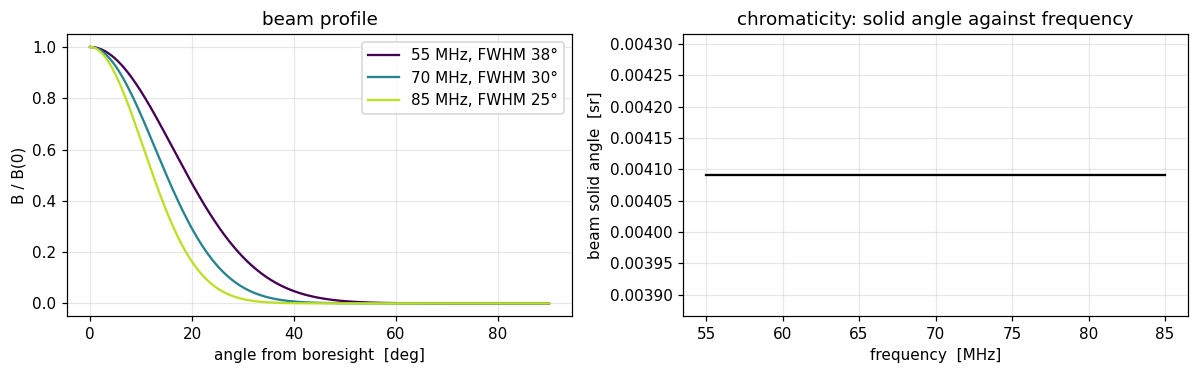

In [2]:
def fwhm_deg(freq):
    return 30.0 * 70.0 / freq

def beam_func(freq, nside):
    return example_symm_beam_map(freq=freq, nside=nside, FWHM=fwhm_deg(freq))

theta = np.linspace(0, 90, 400)
omega = np.array([beam_func(f, NSIDE).sum() * hp.nside2pixarea(NSIDE) for f in FREQS])   # beam solid angle
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for f, c in ((55, COLORS[0]), (70, COLORS[15]), (85, COLORS[30])):
    axes[0].plot(theta, np.exp(-4 * np.log(2) * (theta / fwhm_deg(f)) ** 2), color=c, label=f"{f} MHz, FWHM {fwhm_deg(f):.0f}°")
axes[0].set(xlabel="angle from boresight  [deg]", ylabel="B / B(0)", title="beam profile"); axes[0].legend()
axes[1].plot(FREQS, omega, "k-")
axes[1].set(xlabel="frequency  [MHz]", ylabel="beam solid angle  [sr]", title="chromaticity: solid angle against frequency")
plt.tight_layout()

## The simulated scan

`TODSim` at Jodrell Bank, zenith pointing, GDSM sky. One full sidereal day at a cadence chosen so the last sample lands
exactly one cadence before the first: `LSTWindow` recognises the scan as **closed**.

simulated (359, 31) in 366 s
closed: True   samples: 359   cadence: 1.0028 deg   coverage: 1.000


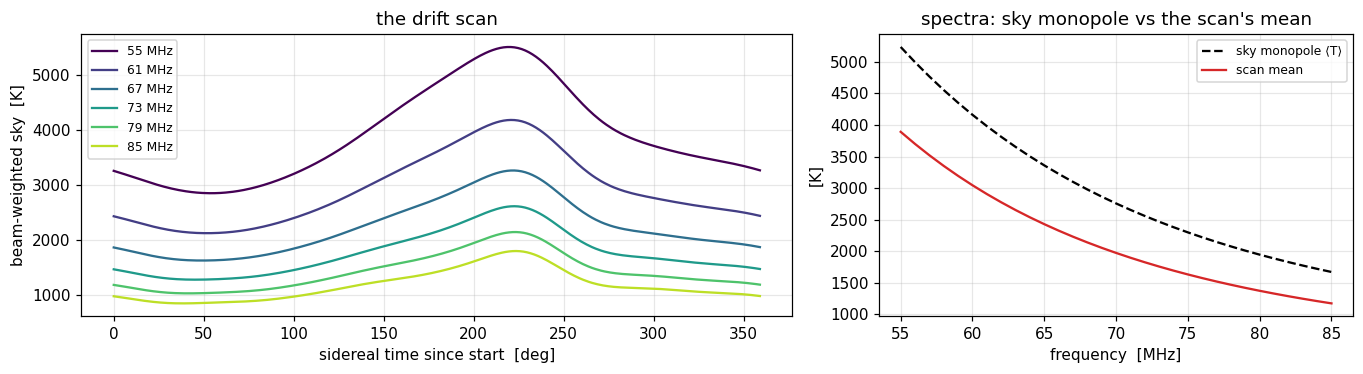

In [3]:
sim = TODSim(**JBO, beam_func=beam_func, sky_func=GDSM_sky_model, beam_nside=NSIDE, sky_nside=NSIDE)

SIDEREAL_DAY = 86164.0905                 # s
N_T = 359                                 # samples: 240 s cadence, closes the circle
t_list = np.arange(N_T) * SIDEREAL_DAY / N_T

t0 = time.time()
tod_sky, lst = sim.simulate_sky_TOD(FREQS, t_list, np.zeros(N_T), 90.0, return_LSTs=True)
tod_sky = tod_sky.T                       # (n_time, n_freq), the layout mmode expects
print(f"simulated {tod_sky.shape} in {time.time()-t0:.0f} s")

window = mmode.LSTWindow(lst, t_ref_deg=lst[0])
print(f"closed: {window.closed}   samples: {window.n}   cadence: {window.cadence_deg:.4f} deg   coverage: {window.coverage:.3f}")
assert window.closed

sky_mono = np.array([GDSM_sky_model(freq=f, nside=NSIDE).mean() for f in FREQS])     # the sky's own monopole
dt_deg = np.unwrap(np.deg2rad(lst)) * 180 / np.pi - lst[0]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.5), gridspec_kw={"width_ratios": [1.5, 1]})
for j in SHOW:
    axes[0].plot(dt_deg, tod_sky[:, j], color=COLORS[j], label=f"{FREQS[j]:.0f} MHz")
axes[0].set(xlabel="sidereal time since start  [deg]", ylabel="beam-weighted sky  [K]", title="the drift scan"); axes[0].legend(fontsize=8)
axes[1].plot(FREQS, sky_mono, "k--", label="sky monopole ⟨T⟩")
axes[1].plot(FREQS, tod_sky.mean(axis=0), "-", color="C3", label="scan mean")
axes[1].set(xlabel="frequency  [MHz]", ylabel="[K]", title="spectra: sky monopole vs the scan's mean"); axes[1].legend(fontsize=8)
plt.tight_layout()

## What the solver returns

### The m-mode spectra

On the closed scan every mode up to $M=40$ is determined (`cond` ≈ 1); this noiseless solve is the **truth**
for what follows. Left: the mode ladder $|d_m|$. Middle and right: the **spectra** $d_m(\nu)$, real and imaginary
parts — the linear components a model has to reproduce.

cond = 1.000   time-series residual rms 0.066 K (pixelisation)


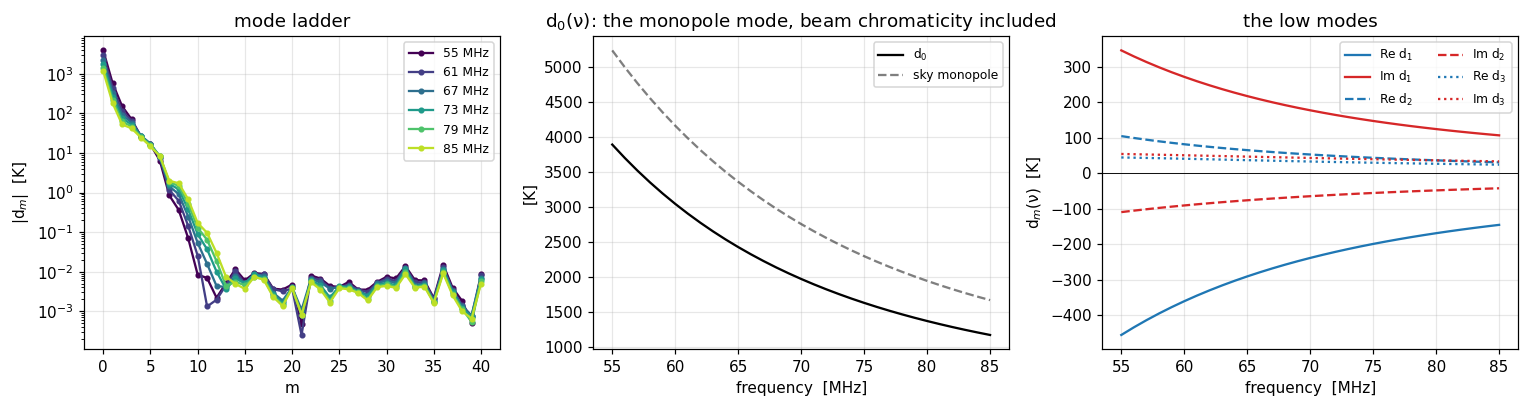

In [4]:
M_ALL = 40
truth = mmode.solve(tod_sky, window, m_trunc=M_ALL)
d_true = truth.modes                                   # (n_freq, M+1) complex
print(f"cond = {truth.cond:.3f}   time-series residual rms {truth.residual_rms.mean():.3f} K (pixelisation)")

m_axis = np.arange(M_ALL + 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for j in SHOW:
    axes[0].semilogy(m_axis, np.abs(d_true[j]), ".-", color=COLORS[j], label=f"{FREQS[j]:.0f} MHz")
axes[0].set(xlabel="m", ylabel="|d$_m$|  [K]", title="mode ladder"); axes[0].legend(fontsize=8)
axes[1].plot(FREQS, d_true[:, 0].real, "k-", label="d$_0$")
axes[1].plot(FREQS, sky_mono, "k--", alpha=0.5, label="sky monopole")
axes[1].set(xlabel="frequency  [MHz]", ylabel="[K]", title="d$_0$(ν): the monopole mode, beam chromaticity included"); axes[1].legend(fontsize=8)
for mm, ls in ((1, "-"), (2, "--"), (3, ":")):
    axes[2].plot(FREQS, d_true[:, mm].real, ls, color="C0", label=f"Re d$_{mm}$")
    axes[2].plot(FREQS, d_true[:, mm].imag, ls, color="C3", label=f"Im d$_{mm}$")
axes[2].axhline(0, color="k", lw=0.6)
axes[2].set(xlabel="frequency  [MHz]", ylabel="d$_m$(ν)  [K]", title="the low modes"); axes[2].legend(fontsize=8, ncol=2)
plt.tight_layout()

### With noise: the error bars are right

White noise of 2 K per sample, deliberately loud. `std_d0()` / `std_mode(m)` come from the sandwich covariance;
the pulls $(\hat d-d)/\sigma$ over every mode and channel are unit-normal.

pull rms over 2511 numbers: 1.01


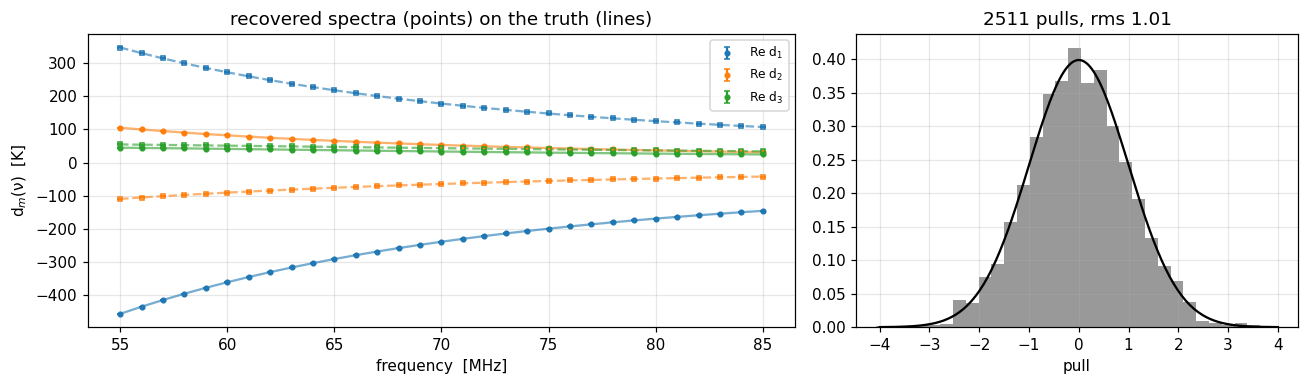

In [5]:
SIGMA = 2.0                                            # K per sample
rng = np.random.default_rng(1)
tod_noisy = tod_sky + rng.normal(0, SIGMA, tod_sky.shape)
est = mmode.solve(tod_noisy, window, m_trunc=M_ALL, sigma=SIGMA)

pulls = [(est.d0 - d_true[:, 0].real) / est.std_d0()]
for mm in range(1, M_ALL + 1):
    s = est.std_mode(mm)
    pulls += [(est.modes[:, mm].real - d_true[:, mm].real) / s[:, 0], (est.modes[:, mm].imag - d_true[:, mm].imag) / s[:, 1]]
pulls = np.concatenate(pulls)
print(f"pull rms over {pulls.size} numbers: {pulls.std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
for mm, c in ((1, "C0"), (2, "C1"), (3, "C2")):
    s = est.std_mode(mm)
    axes[0].errorbar(FREQS, est.modes[:, mm].real, yerr=s[:, 0], fmt="o", ms=3, color=c, capsize=2, label=f"Re d$_{mm}$")
    axes[0].plot(FREQS, d_true[:, mm].real, "-", color=c, alpha=0.6)
    axes[0].errorbar(FREQS, est.modes[:, mm].imag, yerr=s[:, 1], fmt="s", ms=3, color=c, capsize=2, mfc="none")
    axes[0].plot(FREQS, d_true[:, mm].imag, "--", color=c, alpha=0.6)
axes[0].set(xlabel="frequency  [MHz]", ylabel="d$_m$(ν)  [K]", title="recovered spectra (points) on the truth (lines)"); axes[0].legend(fontsize=8)
axes[1].hist(pulls, bins=30, density=True, color="0.6")
x = np.linspace(-4, 4, 200); axes[1].plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), "k")
axes[1].set(xlabel="pull", title=f"{pulls.size} pulls, rms {pulls.std():.2f}")
plt.tight_layout()

### The spectra are smooth: fewer parameters than channels

Each $d_m(\nu)$ is carried by a cubic spline with $P=6$ coefficients against 31 channels. The joint design is a
Kronecker product $E\otimes\Phi$, so this is exactly the per-channel solve followed by a projection onto ${\rm span}(\Phi)$
(`project_onto_basis`); the noise comes down by about $\sqrt{P/N_\nu}$, and the residual against the truth shows what the basis cannot carry.

6 spline coefficients per mode against 31 channels: 5.2x overdetermined


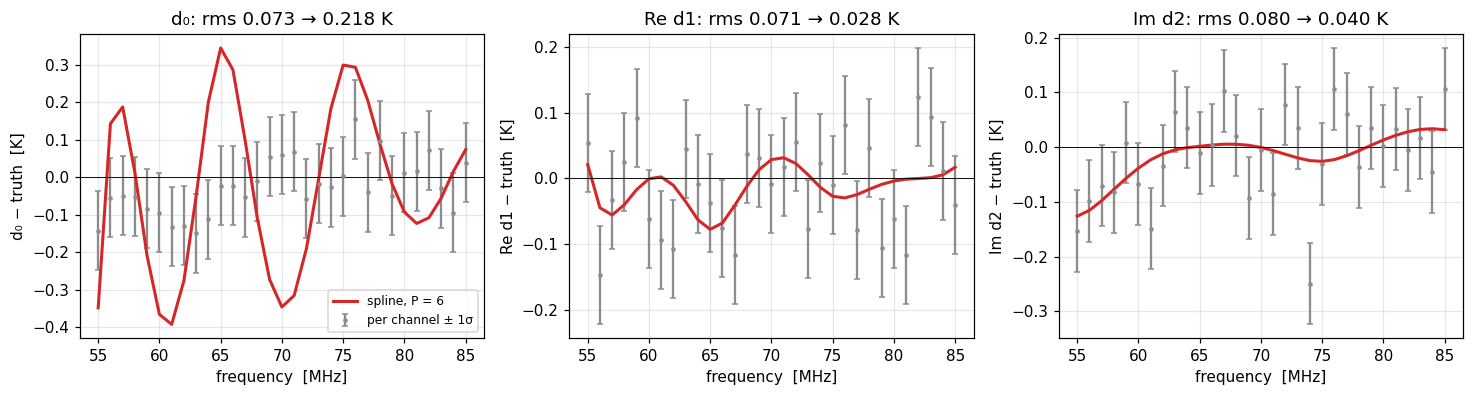

In [6]:
P = 6
basis = mmode.spline_basis(FREQS, P)
print(f"{P} spline coefficients per mode against {FREQS.size} channels: {FREQS.size / P:.1f}x overdetermined")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.7))
for ax, mm, part in ((axes[0], 0, "re"), (axes[1], 1, "re"), (axes[2], 2, "im")):
    raw = est.modes[:, mm].real if part == "re" else est.modes[:, mm].imag
    tru = d_true[:, mm].real if part == "re" else d_true[:, mm].imag
    sig = est.std_d0() if mm == 0 else est.std_mode(mm)[:, 0 if part == "re" else 1]
    fit = mmode.project_onto_basis(raw, basis)
    ax.errorbar(FREQS, raw - tru, yerr=sig, fmt=".", ms=4, color="0.55", capsize=2, label="per channel ± 1σ")
    ax.plot(FREQS, fit - tru, "-", color="C3", lw=2, label=f"spline, P = {P}")
    ax.axhline(0, color="k", lw=0.6)
    lab = "d₀" if mm == 0 else f"{'Re' if part == 're' else 'Im'} d{mm}"
    ax.set(xlabel="frequency  [MHz]", ylabel=f"{lab} − truth  [K]", title=f"{lab}: rms {np.std(raw - tru):.3f} → {np.std(fit - tru):.3f} K")
axes[0].legend(fontsize=8); plt.tight_layout()

### LST smoothing on a partial arc

The general case: a 300° arc, where the modes are no longer orthogonal and the high ones would land on the low
ones. A DPSS kernel with band edge at the truncation ($M=8$) suppresses them; the solve is ordinary least squares
on the smoothed data. Recovered spectra with and without the kernel, on the truth.

arc 300 deg, dpss(L=81, NW=2), band edge m = 8.9, truncation M = 8
no kernel  valid samples  300   cond  2.4e+01   d_0 bias rms   1.57 K   reported sigma 0.89 K
smoothed   valid samples  220   cond  1.3e+04   d_0 bias rms   2.55 K   reported sigma 1.94 K


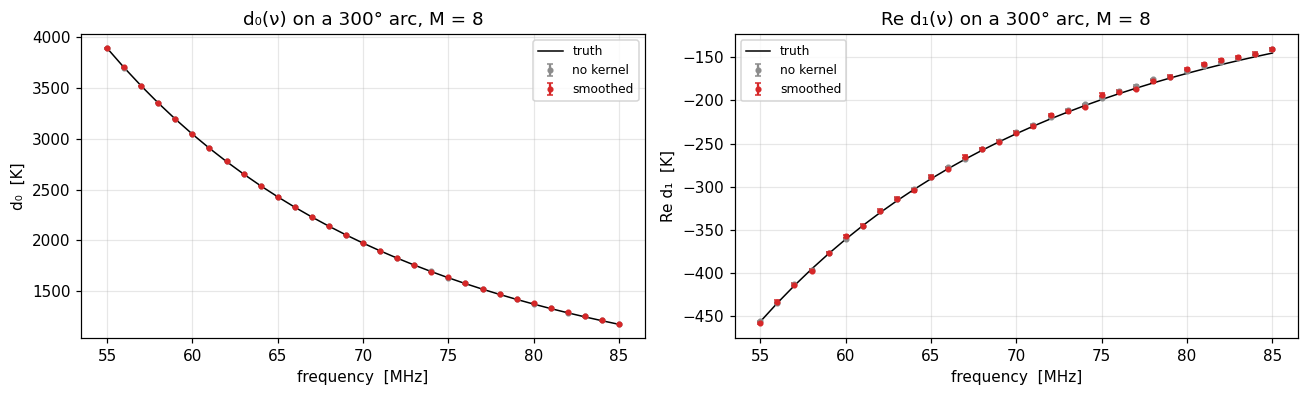

In [7]:
n300 = int(round(300.0 / window.cadence_deg)) + 1
arc300 = mmode.LSTWindow(lst[:n300], t_ref_deg=lst[0])
M_TR = 8
kernel = mmode.dpss_kernel(81, 2.0)
print(f"arc {arc300.span_deg:.0f} deg, {kernel.label}, band edge m = {kernel.band_edge(arc300, 2.0):.1f}, truncation M = {M_TR}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plain = mmode.solve(tod_noisy[:n300], arc300, m_trunc=M_TR, sigma=SIGMA)
    smooth = mmode.solve(tod_noisy[:n300], arc300, m_trunc=M_TR, kernel=kernel, sigma=SIGMA)
for name, r in (("no kernel", plain), ("smoothed", smooth)):
    print(f"{name:10s} valid samples {r.n_valid:4d}   cond {r.cond:8.1e}   "
          f"d_0 bias rms {np.std(r.d0 - d_true[:, 0].real):6.2f} K   reported sigma {r.std_d0()[0]:.2f} K")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.7))
for ax, mm, part in ((axes[0], 0, "re"), (axes[1], 1, "re")):
    tru = d_true[:, mm].real
    for r, c, lab in ((plain, "0.55", "no kernel"), (smooth, "C3", "smoothed")):
        val = r.modes[:, mm].real
        sig = r.std_d0() if mm == 0 else r.std_mode(mm)[:, 0]
        ax.errorbar(FREQS, val, yerr=sig, fmt="o", ms=3, color=c, capsize=2, label=lab)
    ax.plot(FREQS, tru, "k-", lw=1, label="truth")
    ax.set(xlabel="frequency  [MHz]", ylabel=("d₀" if mm == 0 else "Re d₁") + "  [K]",
           title=("d₀(ν)" if mm == 0 else "Re d₁(ν)") + f" on a 300° arc, M = {M_TR}")
    ax.legend(fontsize=8)
plt.tight_layout()

**Reading it.** Without the kernel the scatter of $\hat d_0$ about the truth (1.6 K rms) is nearly twice what the
reported noise says (0.9 K): the modes above $M$ are leaking into it. With the kernel the scatter (2.6 K) is what its
own noise predicts (1.9 K per channel) — the leakage is gone. The price on an open arc is the trimmed samples:
220 of 300 survive, the noise doubles and the conditioning worsens. On a closed scan the modes are orthogonal and
no kernel is needed; on a partial arc it is the kernel that makes the truncated model honest.

### A quiet recovery, with bayesmith posterior samples

Noise of 0.2 K per sample. Every mode up to $m=12$ gets a Gaussian prior of width `envelope[m]` and the raw samples
are observed; bayesmith certifies the model as linear-Gaussian and draws exact posterior samples. The recovered
$d_0(\nu)$ as a spectrum, then about the truth. Skipped if bayesmith is not installed (`pip install limTOD[mmode-bayes]`).

sigma(d_0) per channel: least squares 0.0106 K   posterior 0.0101 K


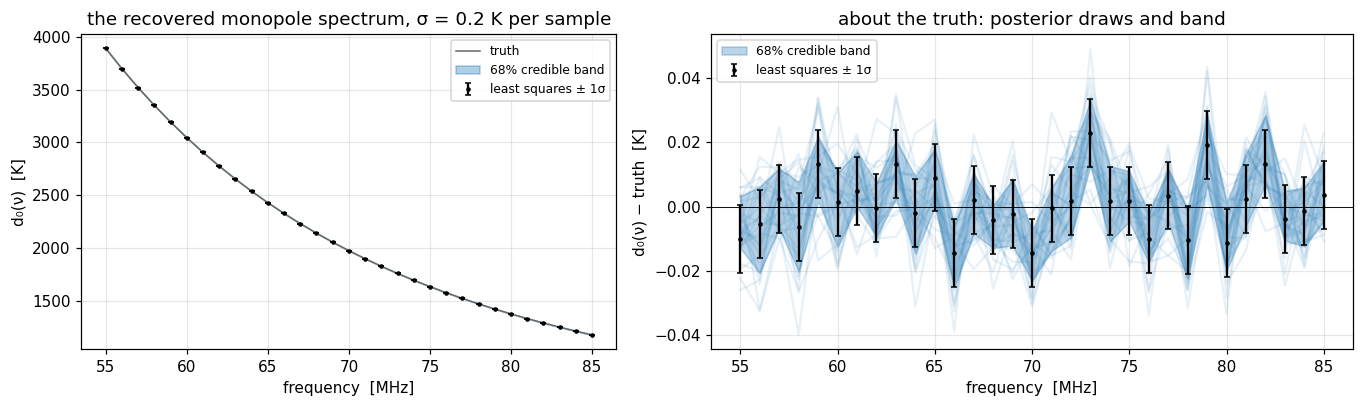

In [8]:
try:
    from limTOD.mmode.bayes import posterior_samples
    M_B = 12
    SIGMA_FINAL = 0.2
    tod_final = tod_sky + np.random.default_rng(3).normal(0, SIGMA_FINAL, tod_sky.shape)
    env = 2 * np.abs(d_true[:, :M_B + 1]).max(axis=0) + 1e-3
    post = posterior_samples(tod_final, window, mmax=M_B, envelope=env, sigma=SIGMA_FINAL, n_draws=30, seed=2)
    lo, hi = post.d0_interval(0.68)
    ls = mmode.solve(tod_final, window, m_trunc=M_B, sigma=SIGMA_FINAL)
    print(f"sigma(d_0) per channel: least squares {ls.std_d0()[0]:.4f} K   posterior {post.std[:, 0].mean():.4f} K")

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw={"width_ratios": [1, 1.2]})
    axes[0].plot(FREQS, d_true[:, 0].real, "-", color="0.4", lw=1, label="truth")
    axes[0].fill_between(FREQS, lo, hi, color="C0", alpha=0.35, label="68% credible band")
    axes[0].errorbar(FREQS, ls.d0, yerr=ls.std_d0(), fmt="k.", ms=4, capsize=2, label="least squares ± 1σ")
    axes[0].set(xlabel="frequency  [MHz]", ylabel="d₀(ν)  [K]", title=f"the recovered monopole spectrum, σ = {SIGMA_FINAL} K per sample"); axes[0].legend(fontsize=8)
    for s in post.samples[:, :, 0].real:
        axes[1].plot(FREQS, s - d_true[:, 0].real, "-", color="C0", alpha=0.1)
    axes[1].fill_between(FREQS, lo - d_true[:, 0].real, hi - d_true[:, 0].real, color="C0", alpha=0.3, label="68% credible band")
    axes[1].errorbar(FREQS, ls.d0 - d_true[:, 0].real, yerr=ls.std_d0(), fmt="k.", ms=4, capsize=2, label="least squares ± 1σ")
    axes[1].axhline(0, color="k", lw=0.6)
    axes[1].set(xlabel="frequency  [MHz]", ylabel="d₀(ν) − truth  [K]", title="about the truth: posterior draws and band"); axes[1].legend(fontsize=8)
    plt.tight_layout()
except ImportError as exc:
    print(exc)